In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [6]:
energy = pd.read_csv("energy_dataset.csv")
weather = pd.read_csv("weather_features.csv")

print("Energy dataset:", energy.shape)
print("Weather dataset:", weather.shape)

Energy dataset: (35064, 29)
Weather dataset: (178396, 17)


In [10]:
print("===== ENERGY DATASET =====")
print(energy.head())

===== ENERGY DATASET =====
                        time  generation biomass  \
0  2015-01-01 00:00:00+01:00               447.0   
1  2015-01-01 01:00:00+01:00               449.0   
2  2015-01-01 02:00:00+01:00               448.0   
3  2015-01-01 03:00:00+01:00               438.0   
4  2015-01-01 04:00:00+01:00               428.0   

   generation fossil brown coal/lignite  generation fossil coal-derived gas  \
0                                 329.0                                 0.0   
1                                 328.0                                 0.0   
2                                 323.0                                 0.0   
3                                 254.0                                 0.0   
4                                 187.0                                 0.0   

   generation fossil gas  generation fossil hard coal  generation fossil oil  \
0                 4844.0                       4821.0                  162.0   
1                 5196.0 

In [11]:
print("===== WEATHER DATASET =====")
print(weather.head())

===== WEATHER DATASET =====
                      dt_iso city_name     temp  temp_min  temp_max  pressure  \
0  2015-01-01 00:00:00+01:00  Valencia  270.475   270.475   270.475      1001   
1  2015-01-01 01:00:00+01:00  Valencia  270.475   270.475   270.475      1001   
2  2015-01-01 02:00:00+01:00  Valencia  269.686   269.686   269.686      1002   
3  2015-01-01 03:00:00+01:00  Valencia  269.686   269.686   269.686      1002   
4  2015-01-01 04:00:00+01:00  Valencia  269.686   269.686   269.686      1002   

   humidity  wind_speed  wind_deg  rain_1h  rain_3h  snow_3h  clouds_all  \
0        77           1        62      0.0      0.0      0.0           0   
1        77           1        62      0.0      0.0      0.0           0   
2        78           0        23      0.0      0.0      0.0           0   
3        78           0        23      0.0      0.0      0.0           0   
4        78           0        23      0.0      0.0      0.0           0   

   weather_id weather_main w

In [12]:
print("===== ENERGY INFO =====")
energy.info()

===== ENERGY INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  str    
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null

In [13]:
print("===== WEATHER INFO =====")
weather.info()

===== WEATHER INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  str    
 1   city_name            178396 non-null  str    
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  str    
 15  wea

In [14]:
print("===== ENERGY MISSING VALUES =====")
print(energy.isnull().sum())

print("\n===== WEATHER MISSING VALUES =====")
print(weather.isnull().sum())

===== ENERGY MISSING VALUES =====
time                                               0
generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation s

In [15]:
print("===== ENERGY MISSING PERCENTAGE =====")
print((energy.isnull().sum() / len(energy) * 100).sort_values(ascending=False))

print("\n===== WEATHER MISSING PERCENTAGE =====")
print((weather.isnull().sum() / len(weather) * 100).sort_values(ascending=False))

===== ENERGY MISSING PERCENTAGE =====
generation hydro pumped storage aggregated     100.000000
forecast wind offshore eday ahead              100.000000
total load actual                                0.102669
generation hydro run-of-river and poundage       0.054187
generation hydro pumped storage consumption      0.054187
generation waste                                 0.054187
generation marine                                0.054187
generation fossil oil                            0.054187
generation biomass                               0.054187
generation fossil peat                           0.051335
generation fossil gas                            0.051335
generation fossil brown coal/lignite             0.051335
generation fossil coal-derived gas               0.051335
generation wind onshore                          0.051335
generation geothermal                            0.051335
generation fossil oil shale                      0.051335
generation fossil hard coal       

1.1 Phân tích các vị trí missing

In [20]:
missing_percentage = (energy.isnull().sum() / len(energy)) * 100

print("===== COLUMNS WITH MISSING VALUES =====")

for column, percentage in missing_percentage.items():
    if percentage > 0:
        print(f"{column}: {percentage:.3f}%")

===== COLUMNS WITH MISSING VALUES =====
generation biomass: 0.054%
generation fossil brown coal/lignite: 0.051%
generation fossil coal-derived gas: 0.051%
generation fossil gas: 0.051%
generation fossil hard coal: 0.051%
generation fossil oil: 0.054%
generation fossil oil shale: 0.051%
generation fossil peat: 0.051%
generation geothermal: 0.051%
generation hydro pumped storage aggregated: 100.000%
generation hydro pumped storage consumption: 0.054%
generation hydro run-of-river and poundage: 0.054%
generation hydro water reservoir: 0.051%
generation marine: 0.054%
generation nuclear: 0.048%
generation other: 0.051%
generation other renewable: 0.051%
generation solar: 0.051%
generation waste: 0.054%
generation wind offshore: 0.051%
generation wind onshore: 0.051%
forecast wind offshore eday ahead: 100.000%
total load actual: 0.103%


In [21]:
# Loại 2 cột bị missing 100%
cols_100_missing = [
    'generation hydro pumped storage aggregated',
    'forecast wind offshore eday ahead'
]

energy_check = energy.drop(columns=cols_100_missing)

# Các dòng có ít nhất một giá trị missing
missing_rows = energy_check[
    energy_check.isnull().any(axis=1)
]

print("Số dòng có missing:", len(missing_rows))

Số dòng có missing: 47


In [22]:
print("Các thời điểm có missing:")

print(
    missing_rows[['time']]
    .to_string(index=False)
)

Các thời điểm có missing:
                     time
2015-01-05 03:00:00+01:00
2015-01-05 12:00:00+01:00
2015-01-05 13:00:00+01:00
2015-01-05 14:00:00+01:00
2015-01-05 15:00:00+01:00
2015-01-05 16:00:00+01:00
2015-01-05 17:00:00+01:00
2015-01-19 19:00:00+01:00
2015-01-19 20:00:00+01:00
2015-01-27 19:00:00+01:00
2015-01-28 13:00:00+01:00
2015-02-01 07:00:00+01:00
2015-02-01 08:00:00+01:00
2015-02-01 09:00:00+01:00
2015-02-01 12:00:00+01:00
2015-02-01 13:00:00+01:00
2015-02-01 14:00:00+01:00
2015-02-01 15:00:00+01:00
2015-02-01 16:00:00+01:00
2015-02-01 17:00:00+01:00
2015-02-01 18:00:00+01:00
2015-02-01 19:00:00+01:00
2015-04-05 03:00:00+02:00
2015-04-16 09:00:00+02:00
2015-04-20 08:00:00+02:00
2015-04-23 21:00:00+02:00
2015-05-02 10:00:00+02:00
2015-05-29 03:00:00+02:00
2015-06-15 09:00:00+02:00
2015-10-02 08:00:00+02:00
2015-10-02 11:00:00+02:00
2015-12-02 09:00:00+01:00
2016-04-13 05:00:00+02:00
2016-04-25 05:00:00+02:00
2016-04-25 07:00:00+02:00
2016-05-10 23:00:00+02:00
2016-06-12 0

In [23]:
missing_pattern = energy_check.isnull().sum(axis=1)

pattern = pd.DataFrame({
    'time': energy_check['time'],
    'missing_count': missing_pattern
})

pattern = pattern[pattern['missing_count'] > 0]

print(pattern.to_string(index=False))

                     time  missing_count
2015-01-05 03:00:00+01:00             20
2015-01-05 12:00:00+01:00             21
2015-01-05 13:00:00+01:00             21
2015-01-05 14:00:00+01:00             21
2015-01-05 15:00:00+01:00             21
2015-01-05 16:00:00+01:00             21
2015-01-05 17:00:00+01:00             21
2015-01-19 19:00:00+01:00             20
2015-01-19 20:00:00+01:00             20
2015-01-27 19:00:00+01:00             20
2015-01-28 13:00:00+01:00             21
2015-02-01 07:00:00+01:00              1
2015-02-01 08:00:00+01:00              1
2015-02-01 09:00:00+01:00              1
2015-02-01 12:00:00+01:00              1
2015-02-01 13:00:00+01:00              1
2015-02-01 14:00:00+01:00              1
2015-02-01 15:00:00+01:00              1
2015-02-01 16:00:00+01:00              1
2015-02-01 17:00:00+01:00              1
2015-02-01 18:00:00+01:00              1
2015-02-01 19:00:00+01:00              1
2015-04-05 03:00:00+02:00              1
2015-04-16 09:00

-> Phân tích mẫu giá trị thiếu: Các giá trị thiếu không hoàn toàn ngẫu nhiên. Một số giá trị thiếu xuất hiện riêng lẻ trong một cột, trong khi những giá trị khác xuất hiện đồng thời trên nhiều cột. Ngoài ra còn có một khoảng thời gian thiếu dữ liệu liên tục từ 12:00 đến 17:00 ngày 05/01/2015, trong đó có 21 cột chứa giá trị thiếu. Do đó, các giá trị thiếu thể hiện cả mẫu riêng lẻ và mẫu theo nhóm.

<Figure size 1500x600 with 0 Axes>

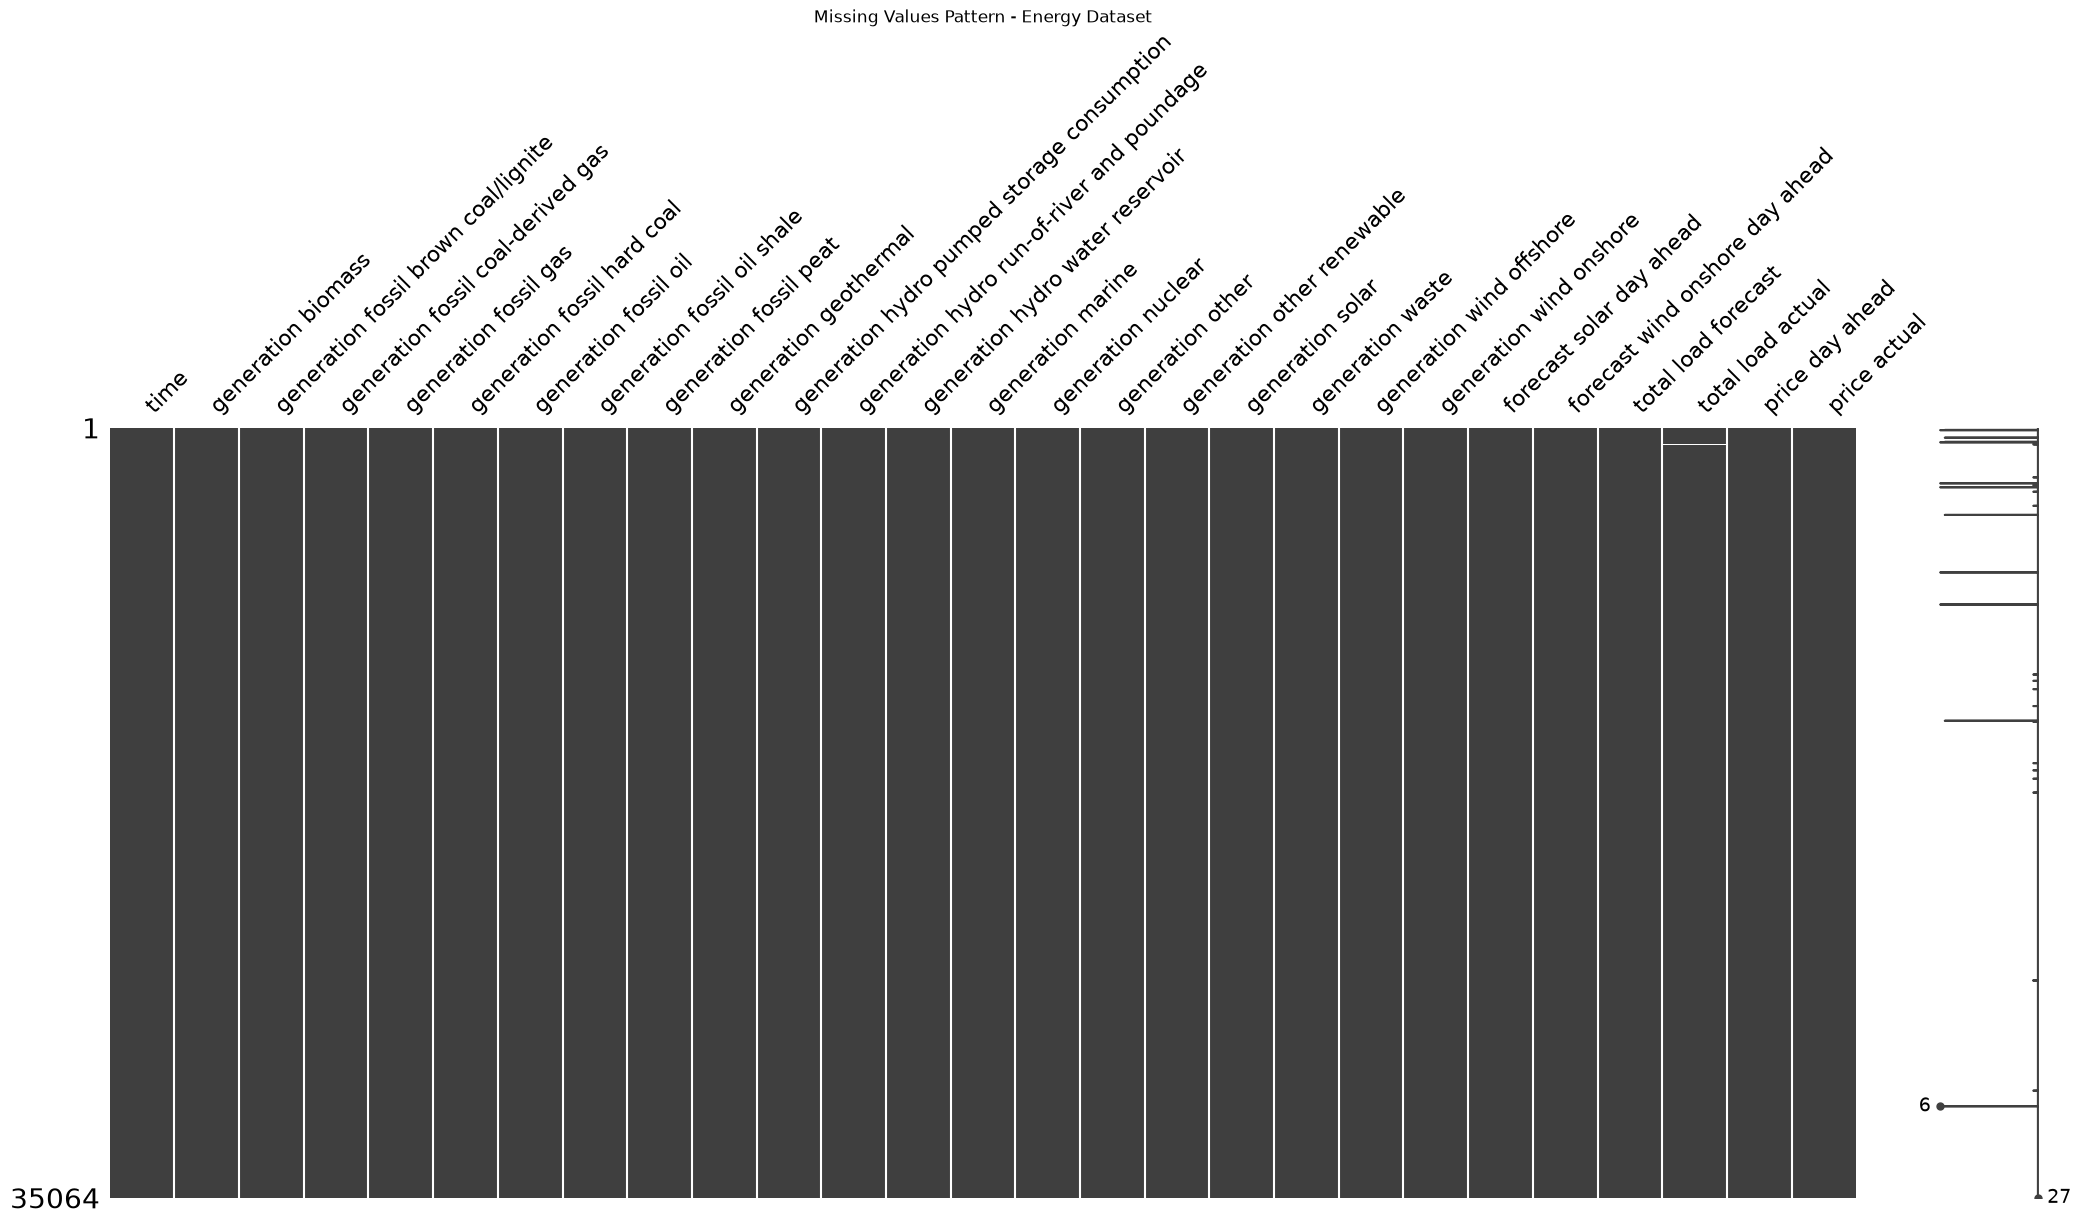

In [24]:
# Visualization of missing values pattern ( Missingno matrix)
plt.figure(figsize=(15, 6))

msno.matrix(energy_check)

plt.title("Missing Values Pattern - Energy Dataset")
plt.show()

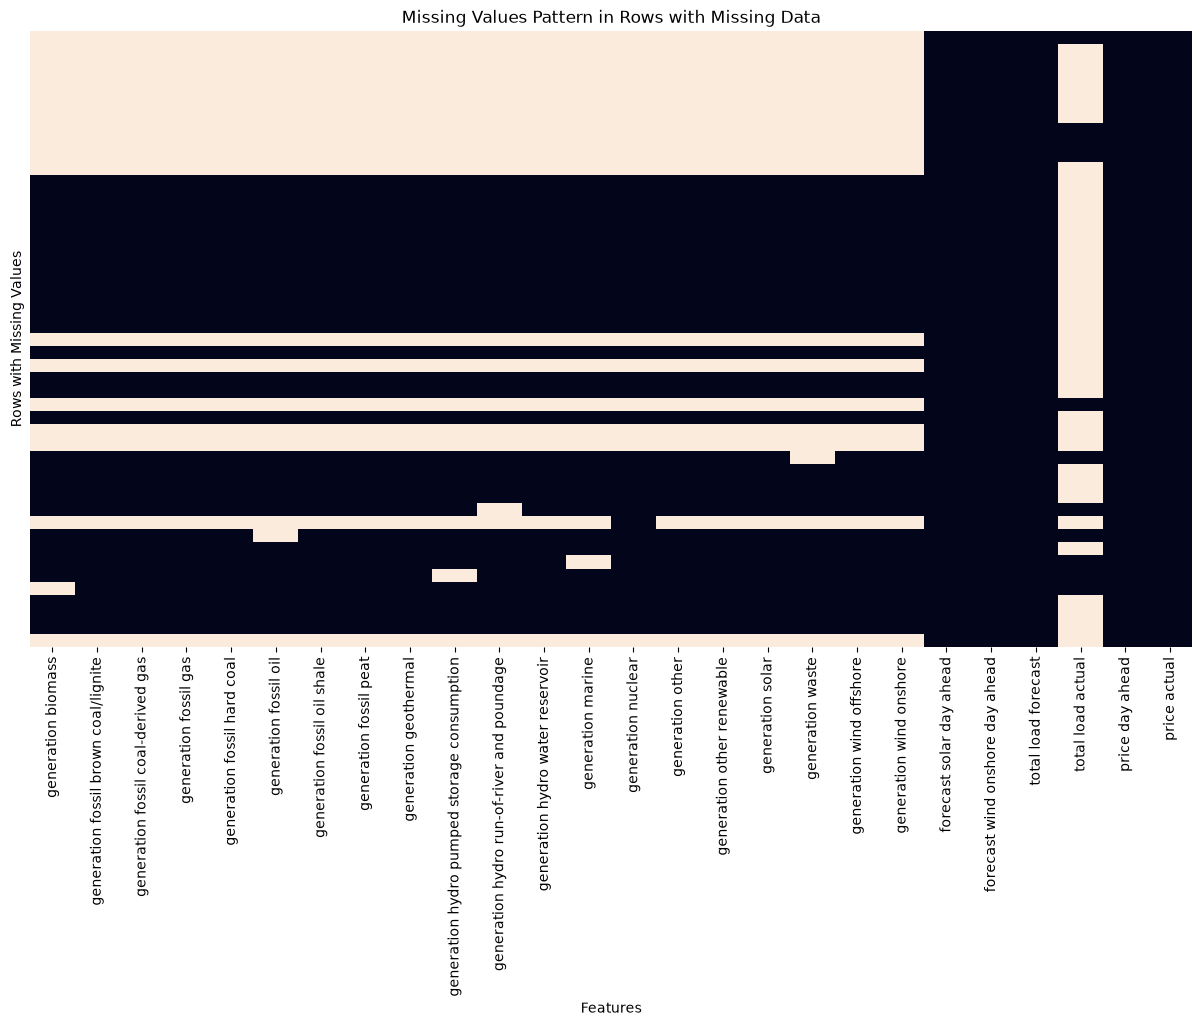

In [25]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    missing_rows.drop(columns=['time']).isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Pattern in Rows with Missing Data")
plt.xlabel("Features")
plt.ylabel("Rows with Missing Values")
plt.show()

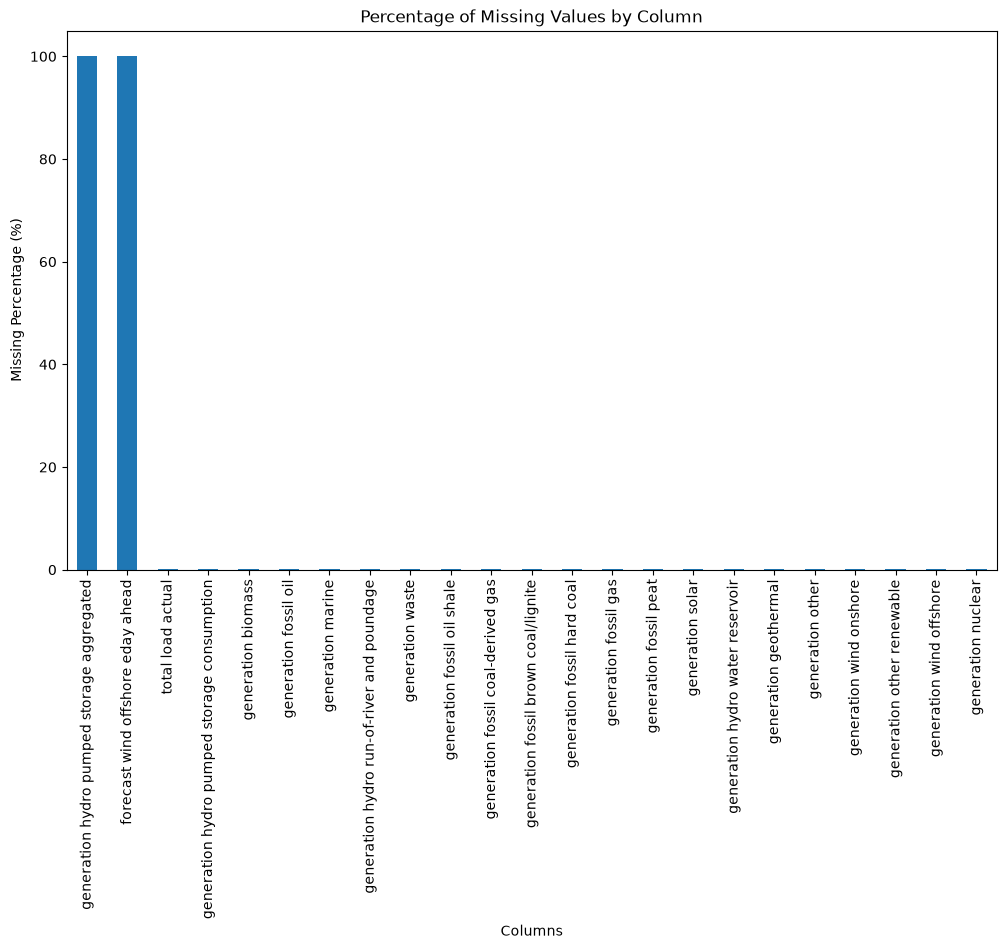

In [26]:
missing_percentage = (
    energy.isnull().sum() / len(energy) * 100
)

missing_percentage = missing_percentage[
    missing_percentage > 0
].sort_values(ascending=False)

plt.figure(figsize=(12, 7))

missing_percentage.plot(kind='bar')

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)
plt.show()

-> Hình ảnh trực quan cho thấy hầu hết tập dữ liệu Năng lượng đều chứa dữ liệu đầy đủ. Hai cột, sản lượng thủy điện tích năng tổng hợp và dự báo điện gió ngoài khơi một ngày tới, có 100% giá trị bị thiếu. Đối với các cột còn lại, giá trị bị thiếu rất ít, dao động từ khoảng 0,048% đến 0,103%. Biểu đồ nhiệt cũng cho thấy các giá trị bị thiếu xuất hiện theo các mô hình khác nhau: một số xuất hiện riêng lẻ trong một cột, trong khi những giá trị khác xuất hiện đồng thời trên nhiều cột và tại các thời điểm liên tiếp.…

-> Phương pháp: Dựa trên phân tích giá trị thiếu, hai cột chứa 100% giá trị thiếu và sẽ bị loại bỏ vì chúng không cung cấp bất kỳ thông tin quan sát nào. Các giá trị thiếu còn lại có tỷ lệ rất nhỏ và xuất hiện trong dữ liệu chuỗi thời gian. Do đó, time-based interpolation sẽ được xem xét cho các biến số dạng số thay vì loại bỏ các hàng tương ứng.

1.2 Xử lý missing

In [27]:
# Xóa 2 cột bị missing 100%
energy_clean = energy.drop(columns=cols_100_missing)

print("Shape before:", energy.shape)
print("Shape after :", energy_clean.shape)

Shape before: (35064, 29)
Shape after : (35064, 27)


In [29]:
# CHuyển cột 'time' sang kiểu datetime (quy chuẩn về UTC để xử lý đổi giờ mùa hè)
energy_clean['time'] = pd.to_datetime(energy_clean['time'], utc=True)

# Sắp xếp theo thời gian
energy_clean = energy_clean.sort_values('time')

print(energy_clean['time'].dtype)

datetime64[us, UTC]


In [31]:
# Interpolation cho các cột số
numeric_cols = energy_clean.select_dtypes(
    include=np.number
).columns

energy_clean[numeric_cols] = (
    energy_clean[numeric_cols]
    .interpolate(method='linear')
)

In [32]:
# Check missing 
print("===== MISSING VALUES AFTER HANDLING =====")

remaining_missing = energy_clean.isnull().sum()

print(
    remaining_missing[
        remaining_missing > 0
    ]
)

print(
    "Total remaining missing values:",
    energy_clean.isnull().sum().sum()
)

===== MISSING VALUES AFTER HANDLING =====
Series([], dtype: int64)
Total remaining missing values: 0


1.3 Kiểm tra dataset sau khi xử lý

In [33]:
print("===== DATASET AFTER HANDLING MISSING VALUES =====")

print("Shape:", energy_clean.shape)

print("\nData types:")
print(energy_clean.dtypes)

===== DATASET AFTER HANDLING MISSING VALUES =====
Shape: (35064, 27)

Data types:
time                                           datetime64[us, UTC]
generation biomass                                         float64
generation fossil brown coal/lignite                       float64
generation fossil coal-derived gas                         float64
generation fossil gas                                      float64
generation fossil hard coal                                float64
generation fossil oil                                      float64
generation fossil oil shale                                float64
generation fossil peat                                     float64
generation geothermal                                      float64
generation hydro pumped storage consumption                float64
generation hydro run-of-river and poundage                 float64
generation hydro water reservoir                           float64
generation marine                              

In [ ]:
# Kiểm tra interpolation 
energy_clean[
    (energy_clean['time'] >= '2015-01-05 10:00:00') &
    (energy_clean['time'] <= '2015-01-05 19:00:00')
]

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
107,2015-01-05 10:00:00+00:00,376.000000,0.0,0.0,3900.000000,2422.000000,333.000000,0.0,0.0,0.0,...,3339.000000,155.0,0.0,9131.000000,3344.0,8921.0,23271.0,24429.0,35.40,80.82
108,2015-01-05 11:00:00+00:00,375.142857,0.0,0.0,3914.714286,2392.714286,333.428571,0.0,0.0,0.0,...,3282.571429,154.0,0.0,8888.142857,3932.0,9258.0,23209.0,24066.0,35.50,79.14
109,2015-01-05 12:00:00+00:00,374.285714,0.0,0.0,3929.428571,2363.428571,333.857143,0.0,0.0,0.0,...,3226.142857,153.0,0.0,8645.285714,4236.0,9156.0,23725.0,23703.0,36.80,73.95
110,2015-01-05 13:00:00+00:00,373.428571,0.0,0.0,3944.142857,2334.142857,334.285714,0.0,0.0,0.0,...,3169.714286,152.0,0.0,8402.428571,4215.0,9072.0,23614.0,23340.0,32.50,71.93
111,2015-01-05 14:00:00+00:00,372.571429,0.0,0.0,3958.857143,2304.857143,334.714286,0.0,0.0,0.0,...,3113.285714,151.0,0.0,8159.571429,4050.0,8779.0,22381.0,22977.0,30.00,71.50
112,2015-01-05 15:00:00+00:00,371.714286,0.0,0.0,3973.571429,2275.571429,335.142857,0.0,0.0,0.0,...,3056.857143,150.0,0.0,7916.714286,3728.0,8426.0,21371.0,22614.0,30.00,71.85
113,2015-01-05 16:00:00+00:00,370.857143,0.0,0.0,3988.285714,2246.285714,335.571429,0.0,0.0,0.0,...,3000.428571,149.0,0.0,7673.857143,3175.0,7946.0,20760.0,22251.0,30.60,80.53
114,2015-01-05 17:00:00+00:00,370.000000,0.0,0.0,4003.000000,2217.000000,336.000000,0.0,0.0,0.0,...,2944.000000,148.0,0.0,7431.000000,2658.0,7617.0,20654.0,21888.0,42.01,89.08
115,2015-01-05 18:00:00+00:00,375.000000,0.0,0.0,4181.000000,2541.000000,333.000000,0.0,0.0,0.0,...,1971.000000,147.0,0.0,6570.000000,1764.0,6837.0,20904.0,22048.0,51.40,90.97
116,2015-01-05 19:00:00+00:00,371.000000,0.0,0.0,4607.000000,2509.000000,334.000000,0.0,0.0,0.0,...,958.000000,153.0,0.0,5549.000000,946.0,5836.0,22334.0,22858.0,55.35,88.51


In [35]:
# Kiểm tra giá trị lỗi
print("Minimum value of each numerical column:")

print(
    energy_clean[numeric_cols]
    .min()
    .sort_values()
)

Minimum value of each numerical column:
generation biomass                                 0.00
generation fossil brown coal/lignite               0.00
generation fossil coal-derived gas                 0.00
generation fossil gas                              0.00
generation fossil hard coal                        0.00
generation fossil oil                              0.00
generation fossil oil shale                        0.00
generation fossil peat                             0.00
generation geothermal                              0.00
generation hydro pumped storage consumption        0.00
generation hydro run-of-river and poundage         0.00
generation hydro water reservoir                   0.00
generation marine                                  0.00
generation nuclear                                 0.00
generation other                                   0.00
generation other renewable                         0.00
generation solar                                   0.00
generati

Kết luận – Xử lý các giá trị thiếu

Bộ dữ liệu Năng lượng ban đầu chứa các giá trị thiếu trong 24 cột. Hai cột có 100% giá trị thiếu và đã bị loại bỏ vì chúng không chứa thông tin quan sát hữu ích nào. Các giá trị thiếu còn lại chiếm chưa đến 0,11% bộ dữ liệu và chủ yếu xuất hiện trong các biến chuỗi thời gian dạng số.

Sau khi phân tích các mẫu giá trị thiếu, phương pháp nội suy tuyến tính được áp dụng cho các giá trị số bị thiếu còn lại. Tập dữ liệu cũng được sắp xếp theo thời gian trước khi nội suy. Sau khi xử lý, tập dữ liệu không còn giá trị thiếu nào và giữ lại 35.064 hàng và 27 cột . Kiểm định cuối cùng cho thấy không có giá trị âm nào được đưa vào các biến số.